<a target="_blank" href="https://colab.research.google.com/github/santineiraher/HE2_Consultor-a_IA_Responsable/blob/main/Semana%2005/scripts/HE2_boosting_clasificacion.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# HE2 Semana 05: Árboles, Random Forest y XGBoost con SHAP

Práctica de clasificación supervisada usando la misma fuente de datos de Semana 04 (`adult.csv`), pero enfocada en modelos de árboles y ensambles.

**Objetivos del cuaderno**
- Implementar **CART**, **Random Forest** y **XGBoost**.
- Evaluar desempeño con métricas de clasificación (`accuracy`, `precision`, `recall`, `f1`, `roc_auc`).
- Hacer tuning con **GridSearchCV** y **RandomizedSearchCV**.
- Enfatizar interpretabilidad con **SHAP**: beeswarm, cascada (waterfall) y feature importance.



In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap # explainable AI

from IPython.display import display
from scipy import sparse

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
try:
    from xgboost import XGBClassifier
except ImportError:
    raise ImportError("No se encontró `xgboost`. Instálalo con: pip install xgboost")

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

TARGET_COL = "income"
RANDOM_STATE = 1999
TEST_SIZE = 0.2
SCORING_MAIN = "f1"
N_ITER_RANDOM_SEARCH = 20

print("Configuración cargada.")
print({
    "TARGET_COL": TARGET_COL,
    "RANDOM_STATE": RANDOM_STATE,
    "TEST_SIZE": TEST_SIZE,
    "SCORING_MAIN": SCORING_MAIN,
    "N_ITER_RANDOM_SEARCH": N_ITER_RANDOM_SEARCH,
})

Configuración cargada.
{'TARGET_COL': 'income', 'RANDOM_STATE': 1999, 'TEST_SIZE': 0.2, 'SCORING_MAIN': 'f1', 'N_ITER_RANDOM_SEARCH': 20}


/opt/anaconda3/envs/pce-2026/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Carga de datos

Usamos exactamente la misma fuente del notebook de clasificación de Semana 04.

## 2. Limpieza mínima y definición del target

- Reemplazamos el marcador de faltantes (`" ?"`) por `NaN`.
- Eliminamos filas incompletas.
- Convertimos `income` a objetivo binario: `0` para `<=50K`, `1` para `>50K`.

In [30]:
url = "https://raw.githubusercontent.com/DataResponsibly/Datasets/master/AdultIncomeData/adult.csv"
df_raw = pd.read_csv(url)
df_raw.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [29]:
df = df_raw.copy()

missing_token = " ?"
df = df.replace(missing_token, np.nan)

print("Filas con faltantes antes de dropna:", df.isna().any(axis=1).sum())
df = df.dropna().copy()
print("Shape luego de dropna:", df.shape)

income_clean = (
    df[TARGET_COL]
    .astype(str)
    .str.strip()
    .str.replace(".", "", regex=False)
)
y = income_clean.str.contains(r">50K").astype(int)
X = df.drop(columns=[TARGET_COL])

print("Valores únicos de y:", sorted(y.unique().tolist()))
if set(y.unique()) != {0, 1}:
    raise ValueError("El target binario no quedó en {0,1}.")

print("Balance de clases (proporción):")
display(y.value_counts(normalize=True).rename("proportion").to_frame())

if X.isna().sum().sum() > 0:
    raise ValueError("Quedaron NaN en X después de la limpieza.")

print("OK: limpieza validada (sin NaN en X, y binaria).")

Filas con faltantes antes de dropna: 2399
Shape luego de dropna: (30162, 15)
Valores únicos de y: [0, 1]
Balance de clases (proporción):


,proportion
income,
0,0.751078
1,0.248922


OK: limpieza validada (sin NaN en X, y binaria).


## 3. Train/Test split

Hacemos partición estratificada para conservar la proporción de clases en train y test.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Tamaños:")
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train mean:", y_train.mean().round(4), "| y_test mean:", y_test.mean().round(4))

Tamaños:
X_train: (24129, 14) | X_test: (6033, 14)
y_train mean: 0.2489 | y_test mean: 0.249


## 4. Preprocesamiento reusable

Como trabajamos con árboles y ensambles, no necesitamos escalar variables numéricas para que el modelo funcione bien. Sí necesitamos codificación para variables categóricas (`OneHotEncoder`).

In [5]:
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print("Numéricas:", len(numeric_features))
print("Categóricas:", len(categorical_features))

# Compatibilidad entre versiones de scikit-learn
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", ohe, categorical_features),
    ]
)

display(pd.DataFrame({
    "numeric_features": pd.Series(numeric_features),
    "categorical_features": pd.Series(categorical_features),
}))

Numéricas: 6
Categóricas: 8


,numeric_features,categorical_features
0,age,workclass
1,fnlwgt,education
2,education-num,marital-status
3,capital-gain,occupation
4,capital-loss,relationship
5,hours-per-week,race
6,NaN,sex
7,NaN,native-country


## 5. Funciones auxiliares (métricas)

Definimos funciones para evitar repetir lógica de evaluación y mantener el cuaderno ordenado.

In [6]:
def evaluate_model(y_true, y_pred, y_prob):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
    }


def fit_and_eval(name, estimator, X_train, y_train, X_test, y_test):
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", estimator),
    ])
    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    metrics_dict = evaluate_model(y_test, y_pred, y_prob)
    metrics_dict["model"] = name
    return pipe, metrics_dict

## 6. Modelos base: CART, Random Forest y XGBoost

Entrenamos los tres modelos con hiperparámetros razonables para obtener una línea base comparable.

In [ ]:
models = {
    "cart": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "rf": RandomForestClassifier(
        n_estimators=400,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "xgb": XGBClassifier(
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_estimators=300,
        learning_rate=0.08,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        n_jobs=-1,  objective="binary:logistic",
      
    ),
}

base_results = []
base_confusions = {}
fitted_base_models = {}

for model_name, model_obj in models.items():
    pipe, metrics_dict = fit_and_eval(model_name, model_obj, X_train, y_train, X_test, y_test)
    base_results.append(metrics_dict)
    fitted_base_models[model_name] = pipe

    y_pred = pipe.predict(X_test)
    base_confusions[model_name] = confusion_matrix(y_test, y_pred)

base_results_df = pd.DataFrame(base_results).sort_values("f1", ascending=False).reset_index(drop=True)
print("Resultados base (ordenados por F1):")
display(base_results_df)

Resultados base (ordenados por F1):


,accuracy,precision,recall,f1,roc_auc,model
0,0.873695,0.789515,0.671771,0.725899,0.931429,xgb
1,0.858942,0.747153,0.655126,0.698120,0.907152,rf
2,0.818664,0.630102,0.657790,0.643648,0.764964,cart


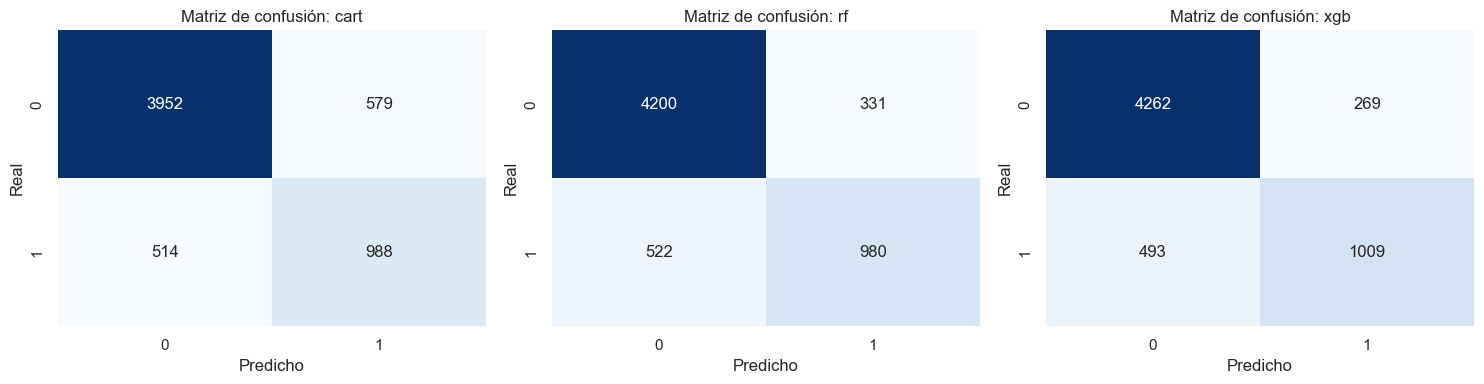

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, model_name in zip(axes, ["cart", "rf", "xgb"]):
    cm = base_confusions[model_name]
    sns.heatmap(cm, annot=True, fmt="d", cbar=False, cmap="Blues", ax=ax)
    ax.set_title(f"Matriz de confusión: {model_name}")
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

## 7. Visualización del árbol CART

Mostramos los primeros niveles para que sea legible (un árbol completo puede ser muy grande).

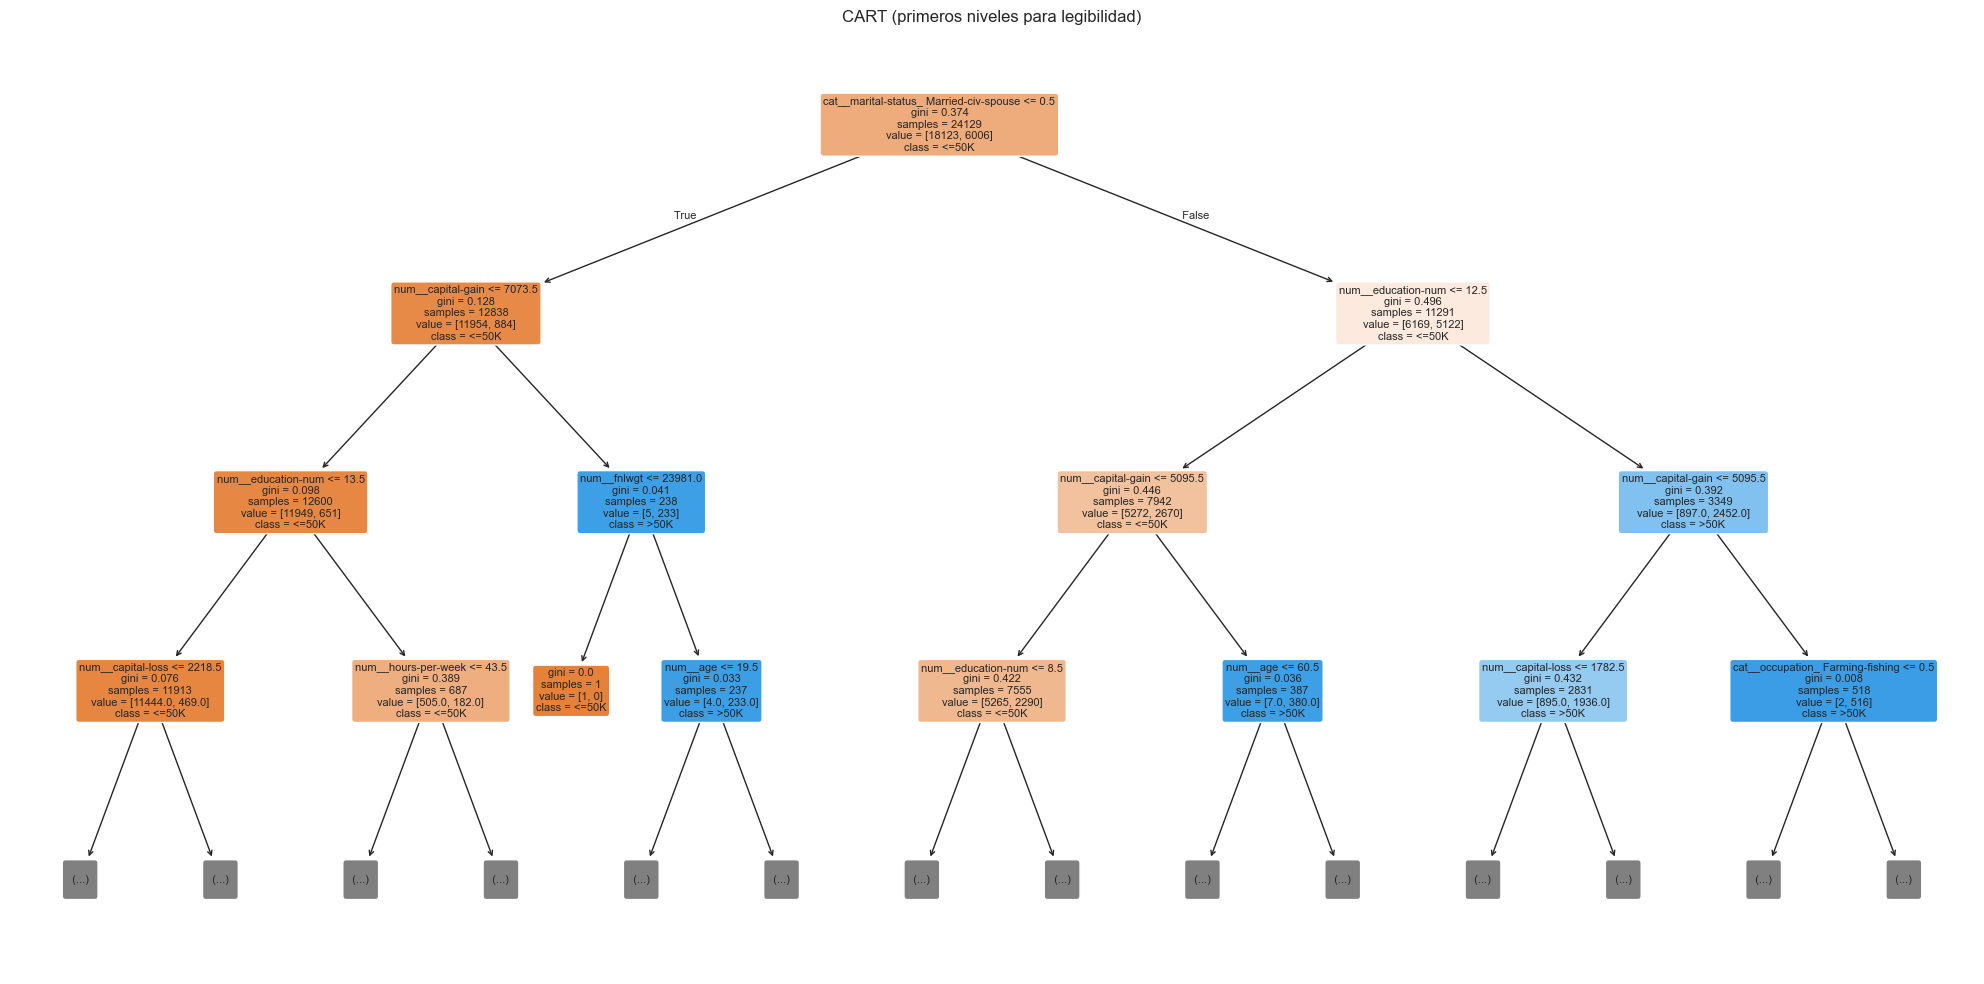

In [33]:
cart_pipe = fitted_base_models["cart"]
cart_model = cart_pipe.named_steps["model"]
feature_names = cart_pipe.named_steps["preprocess"].get_feature_names_out()

plt.figure(figsize=(20, 10))
plot_tree(
    cart_model,
    max_depth=3,
    feature_names=feature_names,
    class_names=["<=50K", ">50K"],
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title("CART (primeros niveles para legibilidad)")
plt.tight_layout()
plt.show()

## 8. Tuning de hiperparámetros

Usamos dos estrategias:

- **GridSearchCV** para CART (espacio relativamente pequeño y fácil de recorrer).
- **RandomizedSearchCV** para RF y XGBoost (espacios de búsqueda más grandes).

La métrica principal de selección es `F1`, para balancear `precision` y `recall`.

In [16]:
print("Iniciando tuning de hiperparámetros...")

# 8.1 GridSearch para CART
cart_pipe_grid = Pipeline([
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

cart_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [3, 5, 8, 12, None],
    "model__min_samples_split": [2, 10, 30],
    "model__min_samples_leaf": [1, 5, 15],
    "model__ccp_alpha": [0.0, 0.001, 0.005],
}

grid_cart = GridSearchCV(
    estimator=cart_pipe_grid,
    param_grid=cart_grid,
    scoring=SCORING_MAIN,
    cv=5,
    n_jobs=-1,
    refit=True,
    verbose=2,
)
grid_cart.fit(X_train, y_train)



print("Tuning finalizado.")

Iniciando tuning de hiperparámetros...
Fitting 5 folds for each of 270 candidates, totalling 1350 fits
[CV] END model__ccp_alpha=0.0, model__criterion=gini, model__max_depth=3, model__min_samples_leaf=1, model__min_samples_split=2; total time=   0.1s
[CV] END model__ccp_alpha=0.0, model__criterion=gini, model__max_depth=3, model__min_samples_leaf=1, model__min_samples_split=2; total time=   0.2s
[CV] END model__ccp_alpha=0.0, model__criterion=gini, model__max_depth=3, model__min_samples_leaf=1, model__min_samples_split=2; total time=   0.2s
[CV] END model__ccp_alpha=0.0, model__criterion=gini, model__max_depth=3, model__min_samples_leaf=1, model__min_samples_split=2; total time=   0.2s
[CV] END model__ccp_alpha=0.0, model__criterion=gini, model__max_depth=3, model__min_samples_leaf=1, model__min_samples_split=2; total time=   0.3s
[CV] END model__ccp_alpha=0.0, model__criterion=gini, model__max_depth=3, model__min_samples_leaf=1, model__min_samples_split=10; total time=   0.3s
[CV] END

In [14]:
# 8.2 RandomizedSearch para RF
rf_pipe_random = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])

rf_distributions = {
    "model__n_estimators": [200, 400, 600, 900],
    "model__max_depth": [None, 8, 12, 16, 22],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__max_features": ["sqrt", "log2", 0.4, 0.7],
}

random_rf = RandomizedSearchCV(
    estimator=rf_pipe_random,
    param_distributions=rf_distributions,
    n_iter=N_ITER_RANDOM_SEARCH,
    scoring=SCORING_MAIN,
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    verbose=2
)
random_rf.fit(X_train, y_train)

print("Tuning finalizado.")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END model__max_depth=22, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=600; total time=  22.3s
[CV] END model__max_depth=22, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=600; total time=  22.3s
[CV] END model__max_depth=22, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=600; total time=  22.7s
[CV] END model__max_depth=12, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=5, model__n_estimators=600; total time=  19.8s
[CV] END model__max_depth=22, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=600; total time=  25.3s
[CV] END model__max_depth=22, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=600; total time=  25.3s
[CV] EN

In [11]:
# 8.3 RandomizedSearch para XGBoost
xgb_pipe_random = Pipeline([
    ("preprocess", preprocess),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

xgb_distributions = {
    "model__n_estimators": [200, 350, 500, 700],
    "model__learning_rate": [0.03, 0.05, 0.08, 0.12],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.75, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5, 8],
    "model__gamma": [0.0, 0.1, 0.3],
    "model__reg_lambda": [0.5, 1.0, 2.0],
}

random_xgb = RandomizedSearchCV(
    estimator=xgb_pipe_random,
    param_distributions=xgb_distributions,
    n_iter=N_ITER_RANDOM_SEARCH,
    scoring=SCORING_MAIN,
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    verbose=2
)
random_xgb.fit(X_train, y_train)

print("Tuning finalizado.")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END model__colsample_bytree=0.9, model__gamma=0.3, model__learning_rate=0.08, model__max_depth=3, model__min_child_weight=3, model__n_estimators=350, model__reg_lambda=1.0, model__subsample=0.7; total time=   2.2s
[CV] END model__colsample_bytree=0.9, model__gamma=0.3, model__learning_rate=0.08, model__max_depth=3, model__min_child_weight=3, model__n_estimators=350, model__reg_lambda=1.0, model__subsample=0.7; total time=   2.2s
[CV] END model__colsample_bytree=0.9, model__gamma=0.3, model__learning_rate=0.08, model__max_depth=3, model__min_child_weight=3, model__n_estimators=350, model__reg_lambda=1.0, model__subsample=0.7; total time=   2.3s
[CV] END model__colsample_bytree=0.75, model__gamma=0.1, model__learning_rate=0.03, model__max_depth=8, model__min_child_weight=3, model__n_estimators=350, model__reg_lambda=1.0, model__subsample=0.7; total time=   3.3s
[CV] END model__colsample_bytree=0.75, model__gamma=0.1, mode

In [36]:
grid_cart.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [18]:
search_objects = {
    "cart_grid": grid_cart,
    "rf_random": random_rf,
    "xgb_random": random_xgb,
}

tuning_results = []
best_estimators = {}

for search_name, search_obj in search_objects.items():
    best_pipe = search_obj.best_estimator_
    y_prob = best_pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    m = evaluate_model(y_test, y_pred, y_prob)
    m.update({
        "search": search_name,
        "best_cv_f1": search_obj.best_score_,
        "best_params": search_obj.best_params_,
    })
    tuning_results.append(m)
    best_estimators[search_name] = best_pipe

tuning_results_df = pd.DataFrame(tuning_results).sort_values("f1", ascending=False).reset_index(drop=True)

print("Resultados tuned (ordenados por F1 en test):")
display(tuning_results_df[["search", "best_cv_f1", "accuracy", "precision", "recall", "f1", "roc_auc"]])

print("Mejores hiperparámetros por búsqueda:")
for _, row in tuning_results_df.iterrows():
    print(f"- {row['search']}: {row['best_params']}")

Resultados tuned (ordenados por F1 en test):


,search,best_cv_f1,accuracy,precision,recall,f1,roc_auc
0,xgb_random,0.716015,0.873529,0.788447,0.672437,0.725835,0.930632
1,rf_random,0.688198,0.862921,0.772397,0.637150,0.698285,0.914995
2,cart_grid,0.671553,0.854799,0.777975,0.583222,0.666667,0.898054


Mejores hiperparámetros por búsqueda:
- xgb_random: {'model__subsample': 0.8, 'model__reg_lambda': 1.0, 'model__n_estimators': 350, 'model__min_child_weight': 5, 'model__max_depth': 4, 'model__learning_rate': 0.08, 'model__gamma': 0.0, 'model__colsample_bytree': 0.6}
- rf_random: {'model__n_estimators': 400, 'model__min_samples_split': 20, 'model__min_samples_leaf': 2, 'model__max_features': 0.7, 'model__max_depth': None}
- cart_grid: {'model__ccp_alpha': 0.0, 'model__criterion': 'entropy', 'model__max_depth': 12, 'model__min_samples_leaf': 15, 'model__min_samples_split': 2}


## 9. SHAP intensivo: explicación global e individual

Ahora profundicemos en la interpretabilidad de los modelos, especialmente el XGBoost, usando SHAP. Para cada modelo, mostraremos:

1. **Beeswarm** (impacto global + dirección del efecto).  
2. **Feature importance SHAP** (promedio de `|SHAP|`).  
3. **Cascada / Waterfall** (explicación local de una observación).  
4. **Dependence plot** para una de las variables más influyentes.

In [19]:
best_row = tuning_results_df.iloc[0]
best_search_name = best_row["search"]
best_pipe = best_estimators[best_search_name]
best_model = best_pipe.named_steps["model"]
best_preprocess = best_pipe.named_steps["preprocess"]

print(f"Mejor modelo tuned por F1 en test: {best_search_name}")

Mejor modelo tuned por F1 en test: xgb_random


In [38]:
type(best_model)
best_model

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [20]:
shap.TreeExplainer(best_model)

In [21]:
X_train_proc = best_preprocess.transform(X_train)
X_test_proc = best_preprocess.transform(X_test)
feature_names = best_preprocess.get_feature_names_out()

if sparse.issparse(X_train_proc):
    X_train_proc = X_train_proc.toarray()
if sparse.issparse(X_test_proc):
    X_test_proc = X_test_proc.toarray()

# Submuestra para acelerar SHAP si el set es grande
n_shap = min(1500, X_test_proc.shape[0])
idx_eval = np.random.RandomState(RANDOM_STATE).choice(
    X_test_proc.shape[0], 
    size=n_shap, 
    replace=False)
X_eval_proc = X_test_proc[idx_eval]

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_eval_proc)

if isinstance(shap_values, list):
    shap_values_for_class_1 = shap_values[1]
    expected_value = explainer.expected_value[1]
else:
    shap_values_for_class_1 = shap_values
    expected_value = explainer.expected_value

print("SHAP preparado para visualización.")

SHAP preparado para visualización.


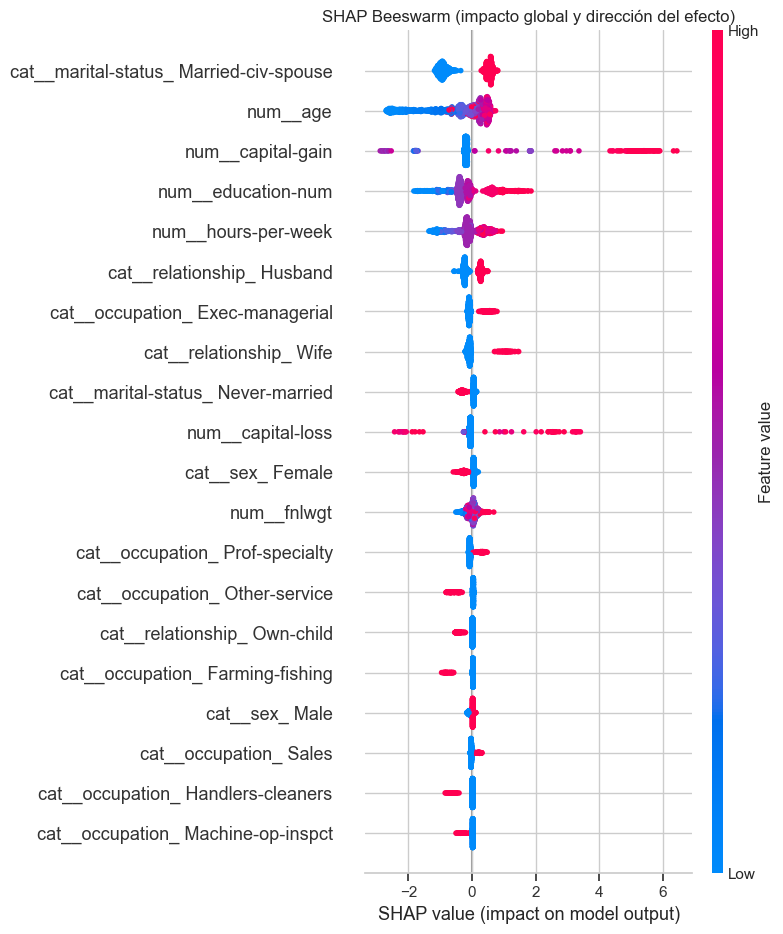

In [22]:
# 9.1 SHAP Beeswarm
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_for_class_1,
    X_eval_proc,
    feature_names=feature_names,
    show=False,
)
plt.title("SHAP Beeswarm (impacto global y dirección del efecto)")
plt.tight_layout()
plt.show()

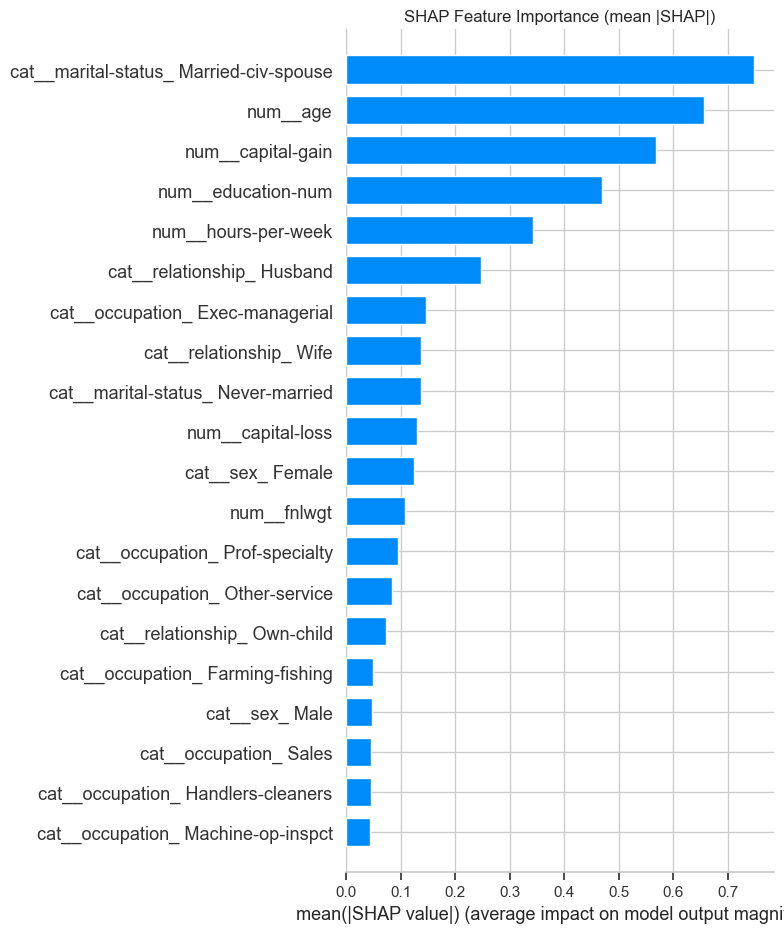

In [23]:
# 9.2 SHAP Feature Importance (bar)
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_for_class_1,
    X_eval_proc,
    feature_names=feature_names,
    plot_type="bar",
    show=False,
)
plt.title("SHAP Feature Importance (mean |SHAP|)")
plt.tight_layout()
plt.show()

In [39]:
expected_value

np.float32(-1.1317307)

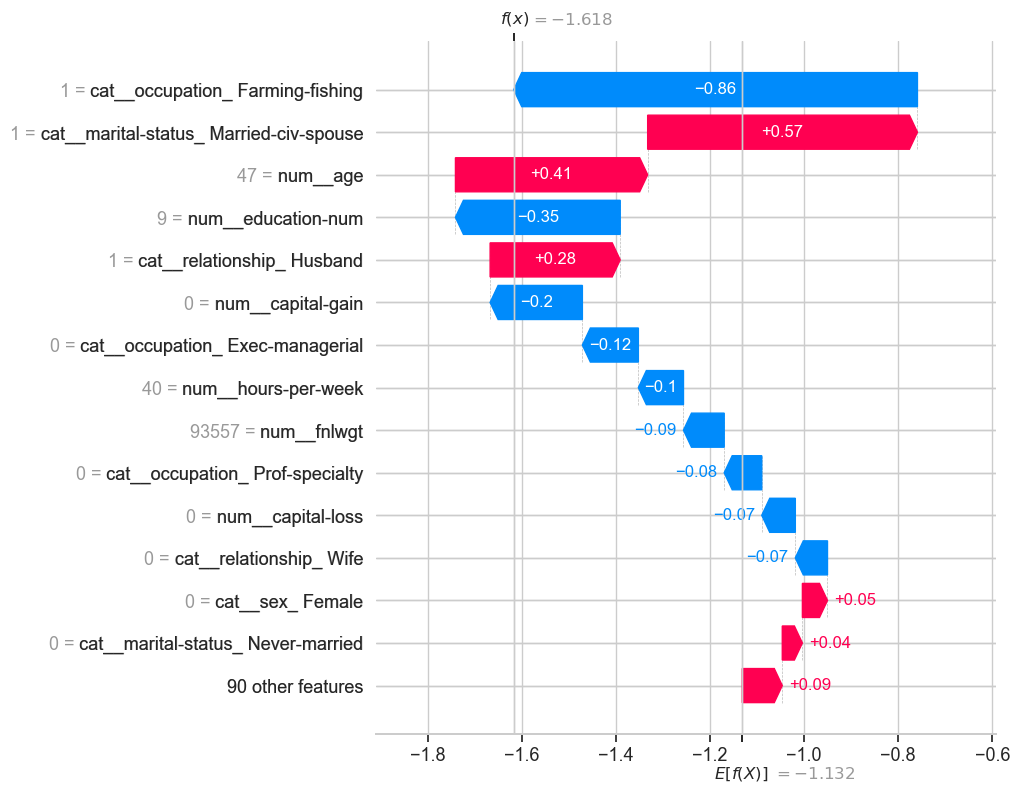

In [24]:
# 9.3 SHAP Cascada / Waterfall (explicación local)
idx_local = 0
local_explanation = shap.Explanation(
    values=shap_values_for_class_1[idx_local],
    base_values=expected_value,
    data=X_eval_proc[idx_local],
    feature_names=feature_names,
)

# Nota: en algunos entornos, waterfall maneja internamente la figura.
shap.plots.waterfall(local_explanation, max_display=15)

Variable con mayor impacto SHAP promedio: cat__marital-status_ Married-civ-spouse


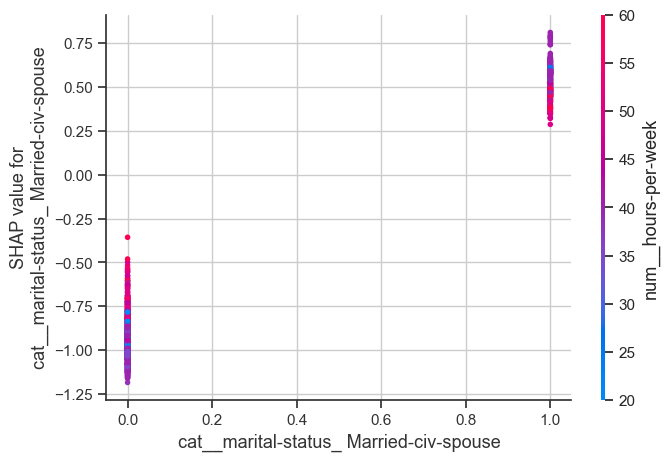

In [31]:
# 9.4 SHAP Dependence Plot (complemento recomendado)
mean_abs_shap = np.abs(shap_values_for_class_1).mean(axis=0)
top_idx = int(np.argmax(mean_abs_shap))
top_feature = feature_names[top_idx]

print("Variable con mayor impacto SHAP promedio:", top_feature)

shap.dependence_plot(
    top_idx,
    shap_values_for_class_1,
    X_eval_proc,
    feature_names=feature_names,
    # interaction_index="auto",
)

### Aclaración importante sobre el valor `f(x)` en SHAP

En modelos como XGBoost, el waterfall suele mostrar `f(x)` en **log-odds** (margen del modelo), no en probabilidad.

- Por eso `f(x)` puede ser negativo o mayor que 1.
- Para llevarlo a probabilidad de clase 1 usamos la sigmoide:

$$
P(y=1) = \frac{1}{1 + e^{-f(x)}}
$$

La siguiente celda hace esa conversión y reporta también la clase predicha con umbral 0.5.

In [26]:
# Conversión de f(x) (log-odds) a probabilidad
fx_log_odds = local_explanation.base_values + local_explanation.values.sum()
prob_clase_1 = 1 / (1 + np.exp(-fx_log_odds))
clase_predicha = int(prob_clase_1 >= 0.5)

print(f"f(x) en log-odds: {fx_log_odds:.4f}")
print(f"Probabilidad clase 1 (>50K): {prob_clase_1:.4f}")
print(f"Clase predicha (umbral=0.5): {clase_predicha}")

f(x) en log-odds: -1.6176
Probabilidad clase 1 (>50K): 0.1655
Clase predicha (umbral=0.5): 0


## 10. Cierre

- **CART** aporta reglas interpretables directamente en forma de árbol.
- **Random Forest** reduce varianza y suele mejorar robustez respecto a un solo árbol.
- **XGBoost** suele alcanzar mejor desempeño tras tuning cuidadoso.
- **SHAP** permite pasar de modelo de alto desempeño a explicaciones accionables, tanto globales como individuales.

Si quieres, en un siguiente paso te lo adapto para que al final imprima automáticamente un breve reporte narrativo para clase (tipo consultoría) con el mejor modelo y sus variables clave.